In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from luwiji.knn import illustration, demo

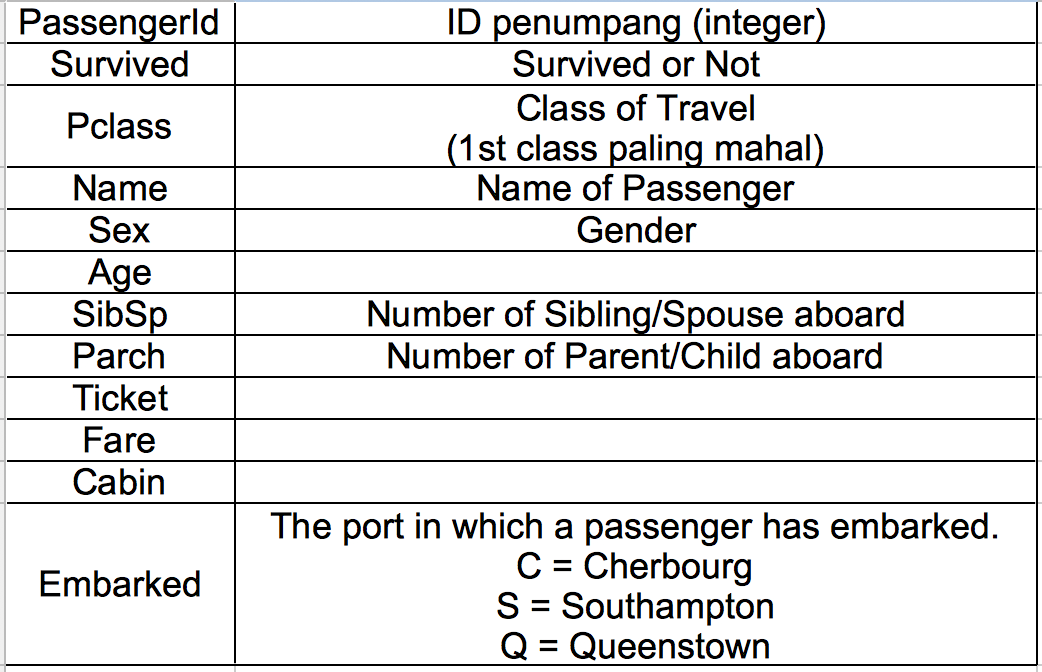

In [ ]:
illustration.nomenklatur

# Read Dataset

In [ ]:
df = pd.read_csv("titanic.csv", index_col="PassengerId")
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 11)

# Quick EDA

## 1. Drop kolom yang tidak digunakan

In [ ]:
df.drop(columns=["Name", "Ticket"], inplace=True)

In [ ]:
df.shape

(891, 9)

## 2. Drop duplikasi data

In [ ]:
print(df.duplicated().sum())

107


In [ ]:
df.drop_duplicates(keep='first', inplace=True)

In [ ]:
df.shape

(784, 9)

## 3. Cek missing value

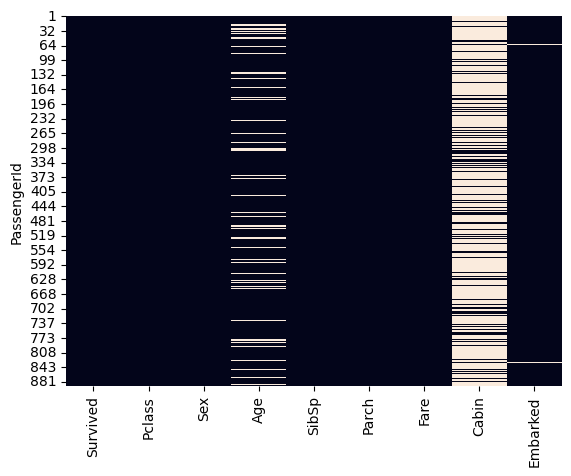

In [ ]:
sns.heatmap(df.isnull(), cbar=False);

In [ ]:
def cek_missing(df):
    return pd.DataFrame({"Jumlah": df.isna().sum(), "Persentase": df.isna().mean() * 100})

In [ ]:
cek_missing(df)

,Jumlah,Persentase
Survived,0,0.000000
Pclass,0,0.000000
Sex,0,0.000000
Age,106,13.520408
SibSp,0,0.000000
Parch,0,0.000000
Fare,0,0.000000
Cabin,581,74.107143
Embarked,2,0.255102


Variabel `Cabin` didrop karena mengandung banyak missing value

In [ ]:
df.drop(columns=["Cabin"], inplace=True)

## 4. Statistika deskriptif

In [ ]:
# numerical columns
df[["Age", "SibSp", "Parch", "Fare"]].describe()

,Age,SibSp,Parch,Fare
count,678.000000,784.000000,784.000000,784.000000
mean,29.869351,0.522959,0.415816,34.711740
std,14.759076,0.986231,0.836922,52.160151
min,0.420000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,8.050000
50%,28.250000,0.000000,0.000000,15.900000
75%,39.000000,1.000000,1.000000,34.109350
max,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Categorical columns
{col: df[col].value_counts() for col in ["Survived", "Pclass", "Sex", "Embarked"]}

{'Survived': Survived
 0    461
 1    323
 Name: count, dtype: int64,
 'Pclass': Pclass
 3    405
 1    214
 2    165
 Name: count, dtype: int64,
 'Sex': Sex
 male      491
 female    293
 Name: count, dtype: int64,
 'Embarked': Embarked
 S    568
 C    155
 Q     59
 Name: count, dtype: int64}

# Materi: Metode Splitting

### 1. Train-Test Split

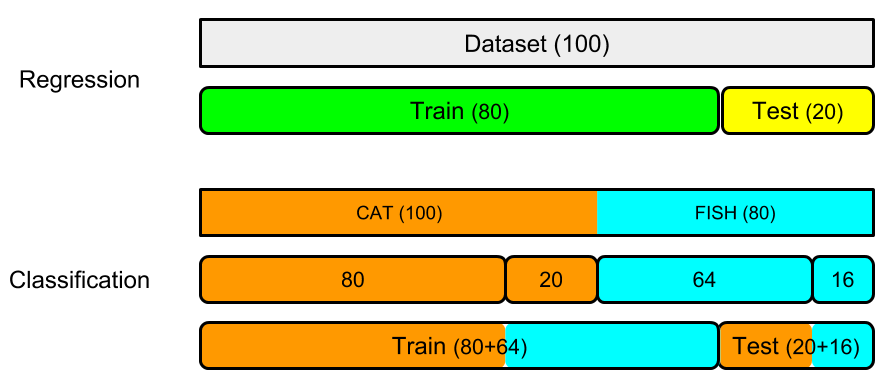

In [ ]:
illustration.train_test_split

Jika kasusnya **KLASIFIKASI** maka menggunakan **STRATIFY** <br>
`stratify = y`

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns=["Survived"])
y = df.Survived

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((627, 7), (157, 7), (627,), (157,))

### 2. K-Fold Cross Validation (K-Fold CV)

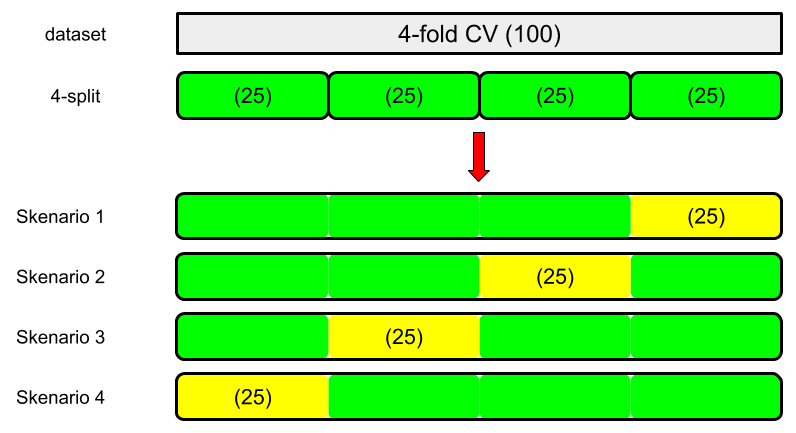

In [ ]:
illustration.kfold_cv

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
# Pre-processing sementara
X_kfold_cv = X.copy()
y_kfold_cv = y.copy()

X_kfold_cv["Age"] = X_kfold_cv["Age"].fillna(X_kfold_cv["Age"].mean())
X_kfold_cv["Embarked"] = X_kfold_cv["Embarked"].fillna(X_kfold_cv["Embarked"].mode()[0])

X_kfold_cv = pd.get_dummies(X_kfold_cv, columns=["Pclass", "Sex", "Embarked"])

# Menggunakan model KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

cross_val_score(knn, X_kfold_cv, y_kfold_cv, cv=4)

array([0.60714286, 0.68877551, 0.61734694, 0.62244898])

In [ ]:
# Skor akhir (rata-rata)
print(f"Skor 5-Fold CV: {cross_val_score(knn, X_kfold_cv, y_kfold_cv, cv=4).mean()}")

Skor 5-Fold CV: 0.6339285714285714


- Biasanya angka K-Fold sekitar 3-5
- Metode K-Fold CV ada banyak, bisa kalian baca di dokumentasi Scikit Learn
- https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py

## 3. Train-Val-Test Split: Avoid the Data Lackage

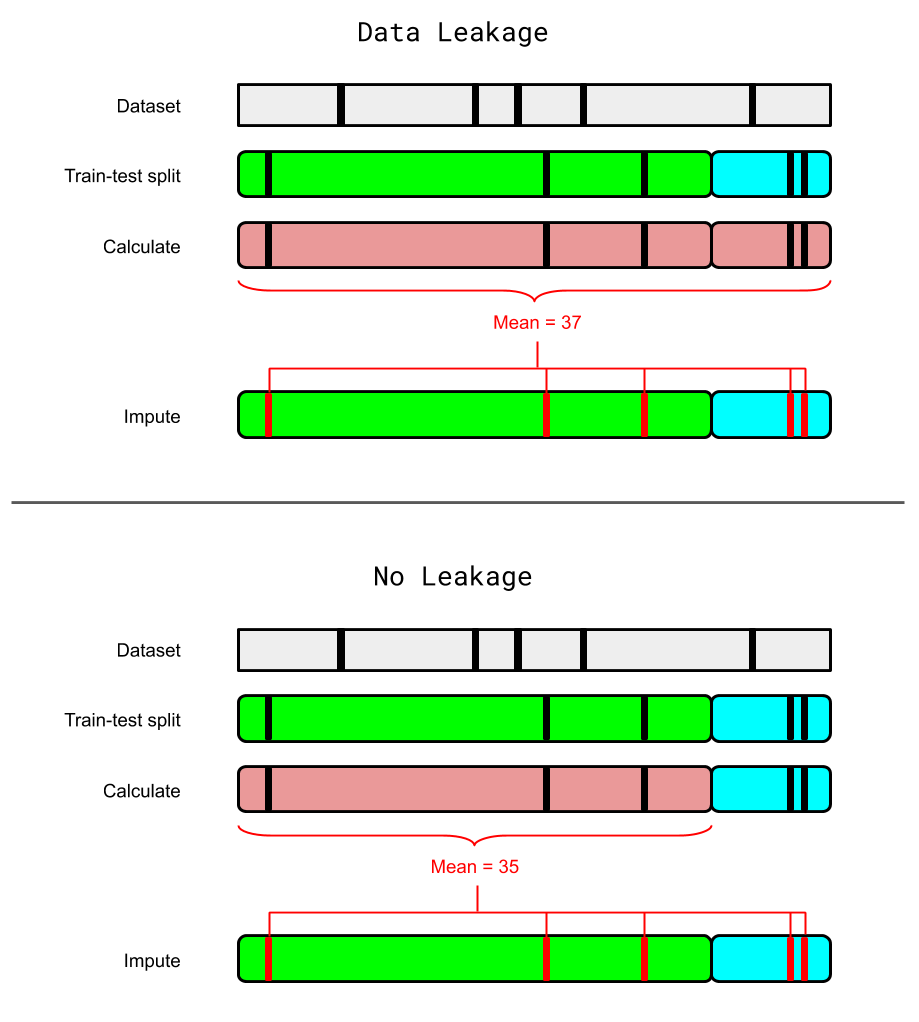

In [ ]:
illustration.data_leakage

Data leakage adalah bocornya informasi data test ketika kita training. Hal ini paling sering terjadi ketika:

- **Imputation**
  - Kita malah impute menggunakan informasi dari seluruh data, harusnya hanya train data saja
  - Solusi: `fit_transform` pada train, `transform` pada test
- **Scaling**
  - Kita malah scaling menggunakan informasi dari seluruh data, harusnya hanya train data saja
  - Solusi: `fit_transform` pada train, `transform` pada test
- K-fold pada train-test split
  - K-fold menyebabkan kita menyentuh data test yang seharusnya tersembunyi
  - Ibaratnya seperti kita boleh retake ujian, ya lama-lama kita jadi tahu soal ujiannya
  - Solusi: train-val-test split

Tips menghindari data leakage:

- Split data sebelum melakukan imputation, scaling
- Jangan pernah fit apapun selain data train, lalu simpan infomasi hasil fit tersebut
- Gunakan train-val-test split

**Train-Val-Test Split**:

Berdasarkan konsep-konsep sebelumnya, maka dapat didesain splitting yang lebih baik menjadi:
- Train set: untuk training
- Validation set: untuk k-fold dan tuning model
- Test set: untuk scoring

Ibaratnya seperti:
- Kerjakan PR: belajar materi
- Quiz yang boleh retake: kita akan retake terus sampai dapat strategi terbaik untuk ujian
- Ujian: gunakan strategi terbaik, scorenya lah yang akan jadi acuan performa kita

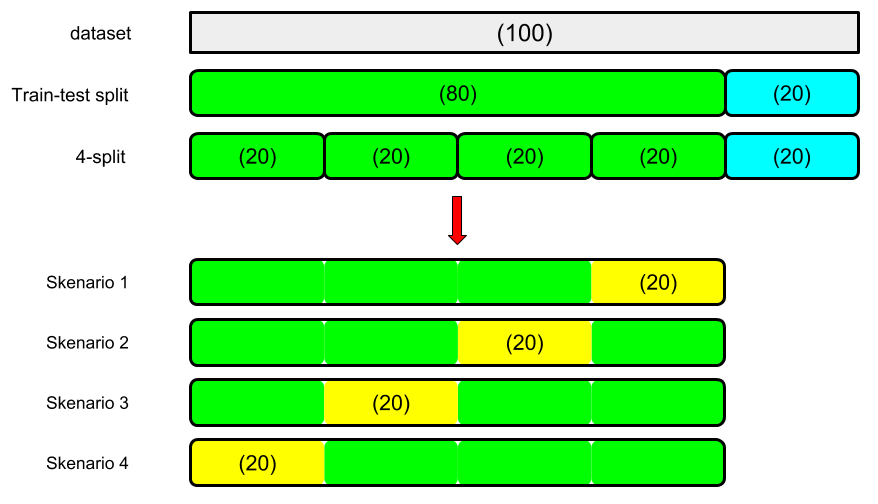

In [ ]:
illustration.train_val_test

# Dataset Splitting

In [ ]:
X = df.drop(columns=["Survived"])
y = df.Survived

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((627, 7), (157, 7), (627,), (157,))

# Pre-Processing: Using Pipeline and Column Transformer

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [ ]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", MinMaxScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", OneHotEncoder())
])

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
numerical_columns = ["Age", "SibSp", "Parch", "Fare"]
categorical_columns = ["Pclass", "Sex", "Embarked"]

preprocessor = ColumnTransformer([
    ("numeric", numerical_pipeline, numerical_columns),
    ("categoric", categorical_pipeline, categorical_columns),
])

# Training

In [ ]:
# Menggunakan model KNN
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("algo", KNeighborsClassifier())
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('categoric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   OneHotEncoder())]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])])),
                ('algo', KNeighborsClassifier())])

In [ ]:
pipeline.score(X_test, y_test)

0.7961783439490446

# Hyperparameter Tuning

In [ ]:
# Menggunakan Grid Search CV
from sklearn.model_selection import GridSearchCV

In [ ]:
# Parameter yang bisa dilakukan tuning
# pipeline.get_params()

In [ ]:
parameter = {
    "algo__n_neighbors" : range(1, 51, 2),
    "algo__weights" : ["uniform", "distance"],
    "algo__p" : [1, 2]
}

model = GridSearchCV(pipeline, parameter, cv=3, n_jobs=-1, verbose=1)
model.fit(X_train, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare']),
                                                                        ('categoric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('scaler',
                                                                                          OneHotEncoder())]),
                                                                         ['Pclass',
                                                                          'Sex',
                                                                          'Embarked'])])),
                                       ('algo', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'algo__n_neighbors': range(1, 51, 2),
                         'algo__p': [1, 2],
                         'algo__weights': ['uniform', 'distance']},
             verbose=1)

In [ ]:
pd.DataFrame(model.cv_results_).sort_values("rank_test_score")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algo__n_neighbors,param_algo__p,param_algo__weights,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
68,0.066490,0.003286,0.093604,0.010258,35,1,uniform,"{'algo__n_neighbors': 35, 'algo__p': 1, 'algo_...",0.775120,0.770335,0.803828,0.783094,0.014790,1
76,0.065267,0.005504,0.117009,0.006122,39,1,uniform,"{'algo__n_neighbors': 39, 'algo__p': 1, 'algo_...",0.770335,0.770335,0.799043,0.779904,0.013533,2
80,0.058635,0.003290,0.106408,0.008041,41,1,uniform,"{'algo__n_neighbors': 41, 'algo__p': 1, 'algo_...",0.765550,0.770335,0.799043,0.778309,0.014790,3
72,0.060647,0.001214,0.096812,0.008400,37,1,uniform,"{'algo__n_neighbors': 37, 'algo__p': 1, 'algo_...",0.770335,0.760766,0.803828,0.778309,0.018462,4
52,0.090416,0.008218,0.160105,0.013256,27,1,uniform,"{'algo__n_neighbors': 27, 'algo__p': 1, 'algo_...",0.779904,0.751196,0.799043,0.776715,0.019663,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,0.060031,0.001889,0.045511,0.004502,3,1,distance,"{'algo__n_neighbors': 3, 'algo__p': 1, 'algo__...",0.736842,0.712919,0.708134,0.719298,0.012558,96
2,0.056355,0.011299,0.083272,0.015644,1,2,uniform,"{'algo__n_neighbors': 1, 'algo__p': 2, 'algo__...",0.703349,0.703349,0.684211,0.696970,0.009022,97
3,0.069962,0.006553,0.049424,0.006418,1,2,distance,"{'algo__n_neighbors': 1, 'algo__p': 2, 'algo__...",0.703349,0.703349,0.684211,0.696970,0.009022,97
0,0.059493,0.009891,0.108454,0.030111,1,1,uniform,"{'algo__n_neighbors': 1, 'algo__p': 1, 'algo__...",0.708134,0.703349,0.665072,0.692185,0.019271,99


In [ ]:
# Best parameter
model.best_params_

{'algo__n_neighbors': 35, 'algo__p': 1, 'algo__weights': 'uniform'}

# Evaluation

In [ ]:
model.score(X_train, y_train), model.score(X_test, y_test)

(0.7783094098883573, 0.821656050955414)

# Prediction

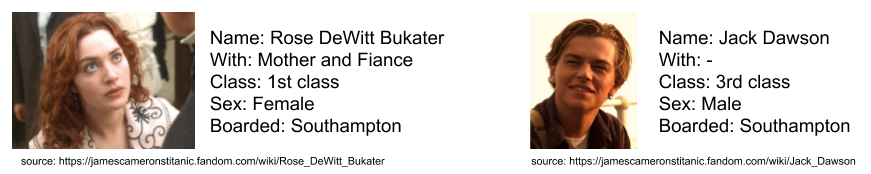

In [ ]:
illustration.jack_and_rose

In [ ]:
X.iloc[0:1]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,
1,3,male,22.0,1,0,7.25,S


In [ ]:
new_data = [
    [1, "female", 25, 1, 1, 80, "S"],
    [3, "male", 28, 0, 0, 5, "S"]
]

X_pred = pd.DataFrame(new_data, index=["Rose", "Jack"], columns=X.columns)
X_pred

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Rose,1,female,25,1,1,80,S
Jack,3,male,28,0,0,5,S


In [ ]:
model.predict(X_pred)

array([1, 0])

In [ ]:
X_pred["Survived"] = model.predict(X_pred)
X_pred

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
Rose,1,female,25,1,1,80,S,1
Jack,3,male,28,0,0,5,S,0


# Save Model

In [ ]:
import pickle

In [ ]:
# Simpan model
pickle.dump(model, open("knn_titanic_v1.pkl", "wb"))

In [ ]:
# Contoh cara load kembali modelnya
model = pickle.load(open("knn_titanic_v1.pkl", "rb"))

## How to Improve Our Model?

Secara umum dibagi menjadi 2:
1. **Improvement melalui data**
    - Feature Engineering
2. **Improvement melalui model**
    - Tuning model yang sedang digunakan
    - Menggunakan model berbeda

### Improvement melalui data
Pada dasarnya terdapat banyak sekali metode feature engineering, dan sangat bergantung dengan kondisi datanya.

Berikut beberapa contoh feature engineering:
- **Missing value imputation**
  - Single imputation
  - Multiple imputation
- **Feature scaling/transformation**
  - logaritmik
  - pangkat
  - trigonometrik
- **Type conversion**
  - categorical to numerical (encoding & hashing)
  - numerical to categorical (binning)
- **Adding feature**
  - domain knowledge
  - feature crossing
  - feature summation or differencing
- **Reducing feature**
  - dimensionality reduction
  - feature importance and selection
- **Text data**
  - flattening
  - filtering
  - chunking